In [16]:
# Install required libraries (run this only once)
!pip install pandas numpy matplotlib nltk scikit-learn

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nltk
import re

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

In [17]:
# Download tokenizer data
nltk.download('punkt')

# Download stopwords dataset
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\tamil\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\tamil\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [19]:
# Path to your dataset file
dataset_path = r"D:\VS Code files\SEM 4\NLP & AI\Projects\Amazon-Product-Reviews-Sentiment-Analysis-in-Python-Dataset.csv"

# Read CSV file using pandas
data = pd.read_csv(dataset_path)

# Display first 5 rows of the dataset
data.head()

,Review,Sentiment
0,Fast shipping but this product is very cheaply...,1
1,This case takes so long to ship and it's not e...,1
2,Good for not droids. Not good for iPhones. You...,1
3,The cable was not compatible between my macboo...,1
4,The case is nice but did not have a glow light...,1


In [20]:
# Remove rows with missing values
data = data.dropna()

# Print dataset size (rows, columns)
print("Dataset Shape:", data.shape)

Dataset Shape: (24999, 2)


In [21]:
# Load English stopwords
stop_words = set(stopwords.words("english"))

# Initialize stemming tool
stemmer = PorterStemmer()

In [22]:
# Function to clean review text
def clean_text(text):

    # Convert text to lowercase
    text = text.lower()

    # Remove numbers and punctuation
    text = re.sub(r'[^a-z\s]', '', text)

    # Split sentence into words
    words = word_tokenize(text)

    # Remove stopwords
    words = [word for word in words if word not in stop_words]

    # Apply stemming (reduce words to root form)
    words = [stemmer.stem(word) for word in words]

    # Join words back into sentence
    return " ".join(words)

In [23]:
# Apply cleaning function to Review column
data["Review"] = data["Review"].apply(clean_text)

# Display updated dataset
data.head()

,Review,Sentiment
0,fast ship product cheapli made brought grandch...,1
1,case take long ship even worth dont buy,1
2,good droid good iphon use featur watch iphon w...,1
3,cabl compat macbook iphon also connector came ...,1
4,case nice glow light im disappoint product did...,1


In [24]:
# X = Input features (review text)
X = data["Review"]

# y = Output labels (sentiment)
y = data["Sentiment"]

In [25]:
# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [26]:
# Initialize TF-IDF vectorizer
vectorizer = TfidfVectorizer()

# Learn vocabulary and transform training text
X_train_vec = vectorizer.fit_transform(X_train)

# Transform test text using learned vocabulary
X_test_vec = vectorizer.transform(X_test)

In [27]:
# Create Logistic Regression model
model = LogisticRegression(max_iter=1000)

# Train the model using training data
model.fit(X_train_vec, y_train)

LogisticRegression(max_iter=1000)

In [28]:
# Predict sentiment for test data
y_pred = model.predict(X_test_vec)

In [29]:
# Calculate accuracy of the model
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.4688


In [30]:
# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[633 244  80  31  33]
 [296 358 207  86  53]
 [105 223 334 230  93]
 [ 45  76 193 399 260]
 [ 40  47  77 237 620]]


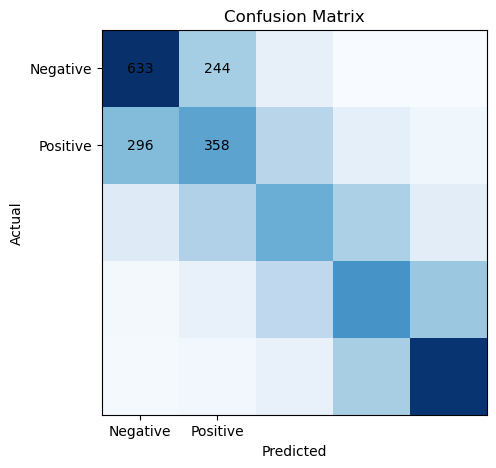

In [31]:
# Create confusion matrix plot
plt.figure(figsize=(5,5))

# Display matrix as image
plt.imshow(cm, cmap="Blues")

# Graph title
plt.title("Confusion Matrix")

# Axis labels
plt.xlabel("Predicted")
plt.ylabel("Actual")

# Axis ticks
plt.xticks([0,1], ["Negative","Positive"])
plt.yticks([0,1], ["Negative","Positive"])

# Display numbers inside matrix
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

# Show plot
plt.show()

In [32]:
# Example review to test the model
review = ["This product is fantastic and very useful"]

# Clean the review
review_clean = clean_text(review[0])

# Convert review to TF-IDF vector
review_vec = vectorizer.transform([review_clean])

# Predict sentiment
prediction = model.predict(review_vec)

# Print result
if prediction[0] == 1:
    print("Sentiment: Positive 😊")
else:
    print("Sentiment: Negative 😞")

Sentiment: Negative 😞


In [ ]:
# Dataset
#    ↓
# Text Cleaning
#    ↓
# Stopword Removal
#    ↓
# Stemming
#    ↓
# TF-IDF Vectorization
#    ↓
# Logistic Regression Model
#    ↓
# Accuracy Evaluation
#    ↓
# Confusion Matrix
#    ↓
# Predict New Review